In [10]:
!pip install xgboost category_encoders optuna


In [11]:
+ Code

NameError: name 'Code' is not defined

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from google.colab import files
uploaded = files.upload()



Saving insurance.csv.csv to insurance.csv (1).csv


In [20]:
import pandas as pd

df = pd.read_csv("insurance.csv (1).csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
print(df.shape)

print(df.info())

print(df.describe())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.

In [22]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


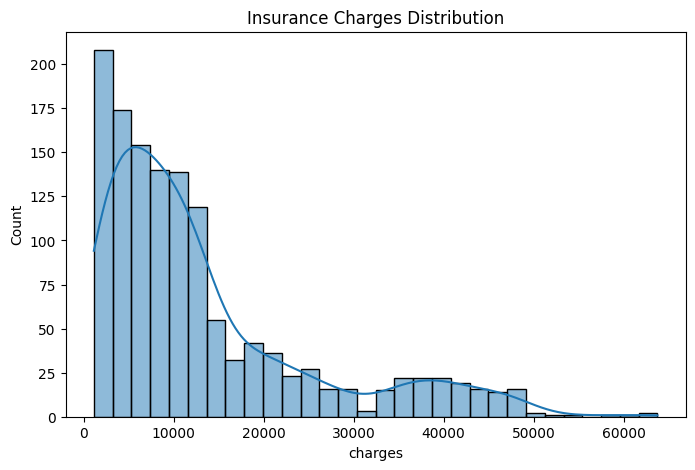

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    df['charges'],
    kde=True
)

plt.title("Insurance Charges Distribution")

plt.show()

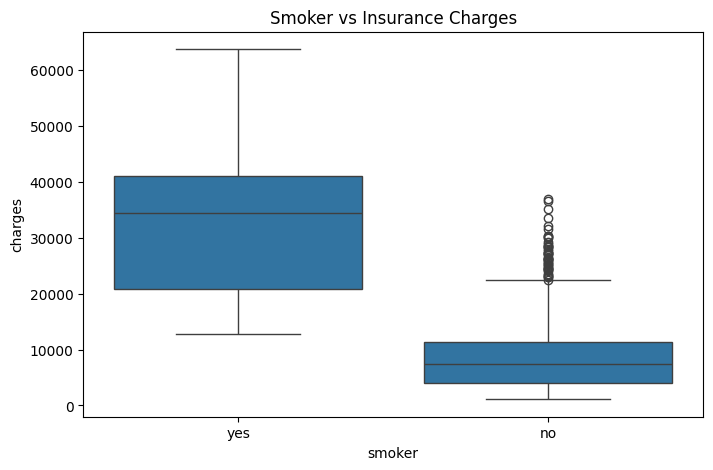

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoker',
    y='charges',
    data=df
)

plt.title("Smoker vs Insurance Charges")

plt.show()

In [26]:
import numpy as np

df['bmi_age_interaction'] = (
    df['bmi'] * df['age']
)

df['is_obese'] = np.where(
    df['bmi'] > 30,
    1,
    0
)

df['high_risk'] = np.where(
    (df['smoker'] == 'yes') &
    (df['bmi'] > 30),
    1,
    0
)

In [27]:
X = df.drop(columns=['charges'])

y = df['charges']

In [28]:
y = np.log1p(y)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1070, 9)
(268, 9)


In [30]:
categorical_cols = [
    'sex',
    'smoker',
    'region'
]

numerical_cols = [
    'age',
    'bmi',
    'children',
    'bmi_age_interaction',
    'is_obese',
    'high_risk'
]

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        ),
        (
            'num',
            'passthrough',
            numerical_cols
        )
    ]
)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

baseline_pipeline.fit(
    X_train,
    y_train
)

print("Baseline model trained.")

Baseline model trained.


In [33]:
baseline_preds = baseline_pipeline.predict(
    X_test
)

In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

baseline_mae = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(baseline_preds)
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 3611.4503649640046


In [35]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        )
    )
])

In [36]:
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    xgb_pipeline,
    param_grid,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

search.fit(
    X_train,
    y_train
)

best_model = search.best_estimator_

print("Best model trained.")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best model trained.


In [39]:
y_pred_log = best_model.predict(
    X_test
)

# reverse log transform

y_test_actual = np.expm1(y_test)

y_pred_actual = np.expm1(y_pred_log)

In [40]:
mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

print("MAE :", mae)

print("RMSE:", rmse)

print("R2  :", r2)

MAE : 2095.5987053112462
RMSE: 4415.551312205951
R2  : 0.8744138312540297


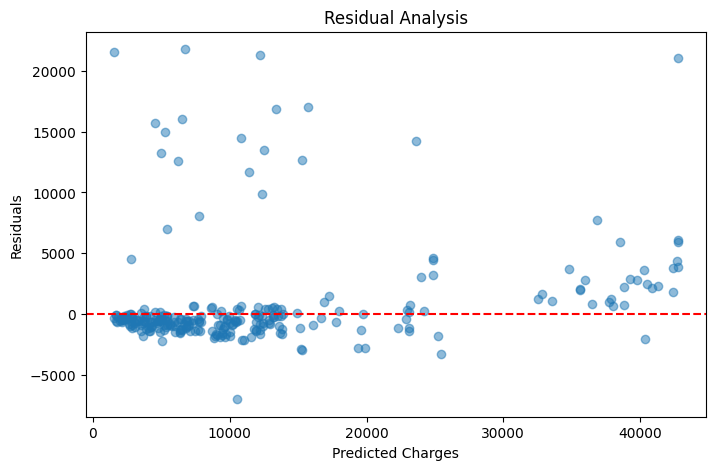

In [41]:
residuals = (
    y_test_actual -
    y_pred_actual
)

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_actual,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Charges")

plt.ylabel("Residuals")

plt.title("Residual Analysis")

plt.show()

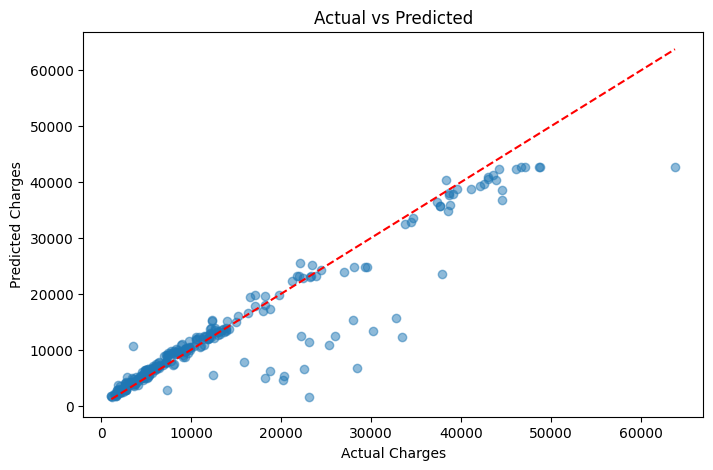

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.5
)

plt.plot(
    [
        y_test_actual.min(),
        y_test_actual.max()
    ],
    [
        y_test_actual.min(),
        y_test_actual.max()
    ],
    'r--'
)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()

In [43]:
feature_names = (
    best_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    best_model
    .named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)


,Feature,Importance
2,cat__smoker_no,0.806182
8,num__age,0.117969
10,num__children,0.018826
9,num__bmi,0.012543
5,cat__region_northwest,0.011574
4,cat__region_northeast,0.010428
0,cat__sex_female,0.008902
11,num__bmi_age_interaction,0.006460
7,cat__region_southwest,0.005652
6,cat__region_southeast,0.001463


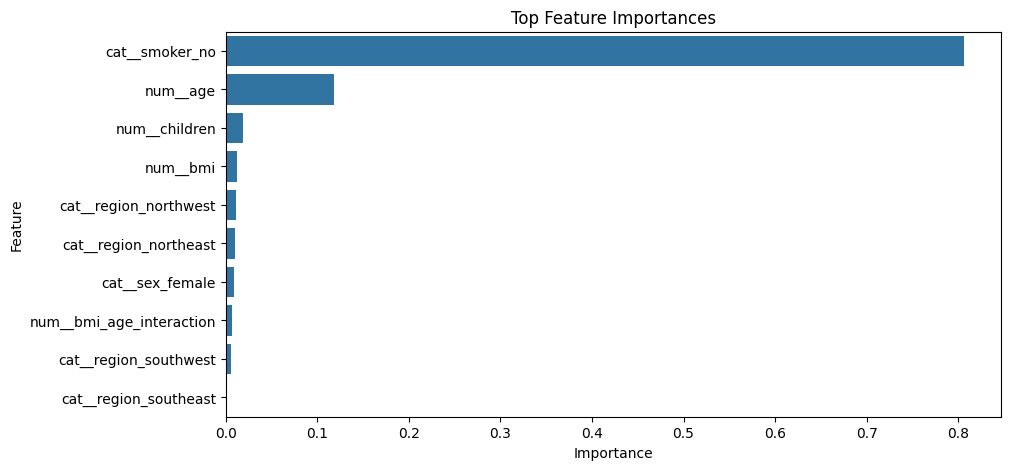

In [44]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Feature Importances")

plt.show()

In [45]:
import joblib

joblib.dump(
    best_model,
    "insurance_pricing_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
